In [4]:
import numpy as np
import os
import pandas as pd
import bayes_pce_multi_fidelity_model as pce
np.random.seed(42)


In [5]:
version = 'vpce1.1'
if not os.path.exists(f'out/{version}'):
   os.makedirs(f'out/{version}')
   
# Set parameter name/x_labels -> needs to be consistent with data input file
x_labels=['Radius[cm]','Thickness[cm]','NPanels', 'Theta[deg]', 'Length[cm]']
x_labels_out = ['Radius r[cm]','Thickness d[cm]','NPanels', 'Angle \\varphi[deg]', 'Length L[cm]']

y_label_sim = 'rGe77[nuc/(kg*yr)]'
y_label_cnp = "Ge-77_CNP"

LF_noise = 0.028


In [6]:
file_in=f'Ge77_rates_CNP_{version}.csv'
data_train=pd.read_csv(f'../baseline_models_comparison/in/{file_in}')
row_hf=data_train.index[data_train['Mode'] == 1]
row_lf=data_train.index[data_train['Mode'] == 0]

x_hf = data_train.loc[row_hf][x_labels].to_numpy()
y_hf = data_train.loc[row_hf][y_label_sim].to_numpy()

x_lf = data_train.loc[row_lf][x_labels].to_numpy()
y_lf = data_train.loc[row_lf][ y_label_sim].to_numpy()

In [7]:
data_test=pd.read_csv("../baseline_models_comparison/in/hf_validation_data_v1.2.csv")
row_hf_test=data_test.index[data_test['Mode'] == 1]
row_lf_test=data_test.index[data_test['Mode'] == 0]
x_test = data_test.loc[row_hf_test][x_labels].to_numpy()
y_test = data_test.loc[row_hf_test][y_label_sim].to_numpy()

In [8]:
# Initialize the model
trainings_data = {"lf": [x_lf,y_lf], "hf": [x_hf,y_hf]}
test_data = {"hf": [x_test,y_test]}

# Prior configurations
priors = {
    "lf": {"sigma_coeffs": 0.5, "sigma": 0.01},
    "hf": {"sigma_rho": 0.08, "sigma_coeffs_delta": 0.005, "sigma": 0.005}
}



In [9]:
# Initialize the multi-fidelity model
multi_fidelity_model = pce.PCEMultiFidelityModel(trainings_data, priors, degree=1)

In [10]:
# Build the model
multi_fidelity_model.build_model()
trace=multi_fidelity_model.run_inference()

/Users/aschuetz/.local/modules/miniconda/miniconda3/envs/pymc-env/lib/python3.10/site-packages/rich/live.py:231: 
UserWarning: install "ipywidgets" for Jupyter support
  warnings.warn('install "ipywidgets" for Jupyter support')

Finished [100%]: Average Loss = -142.25


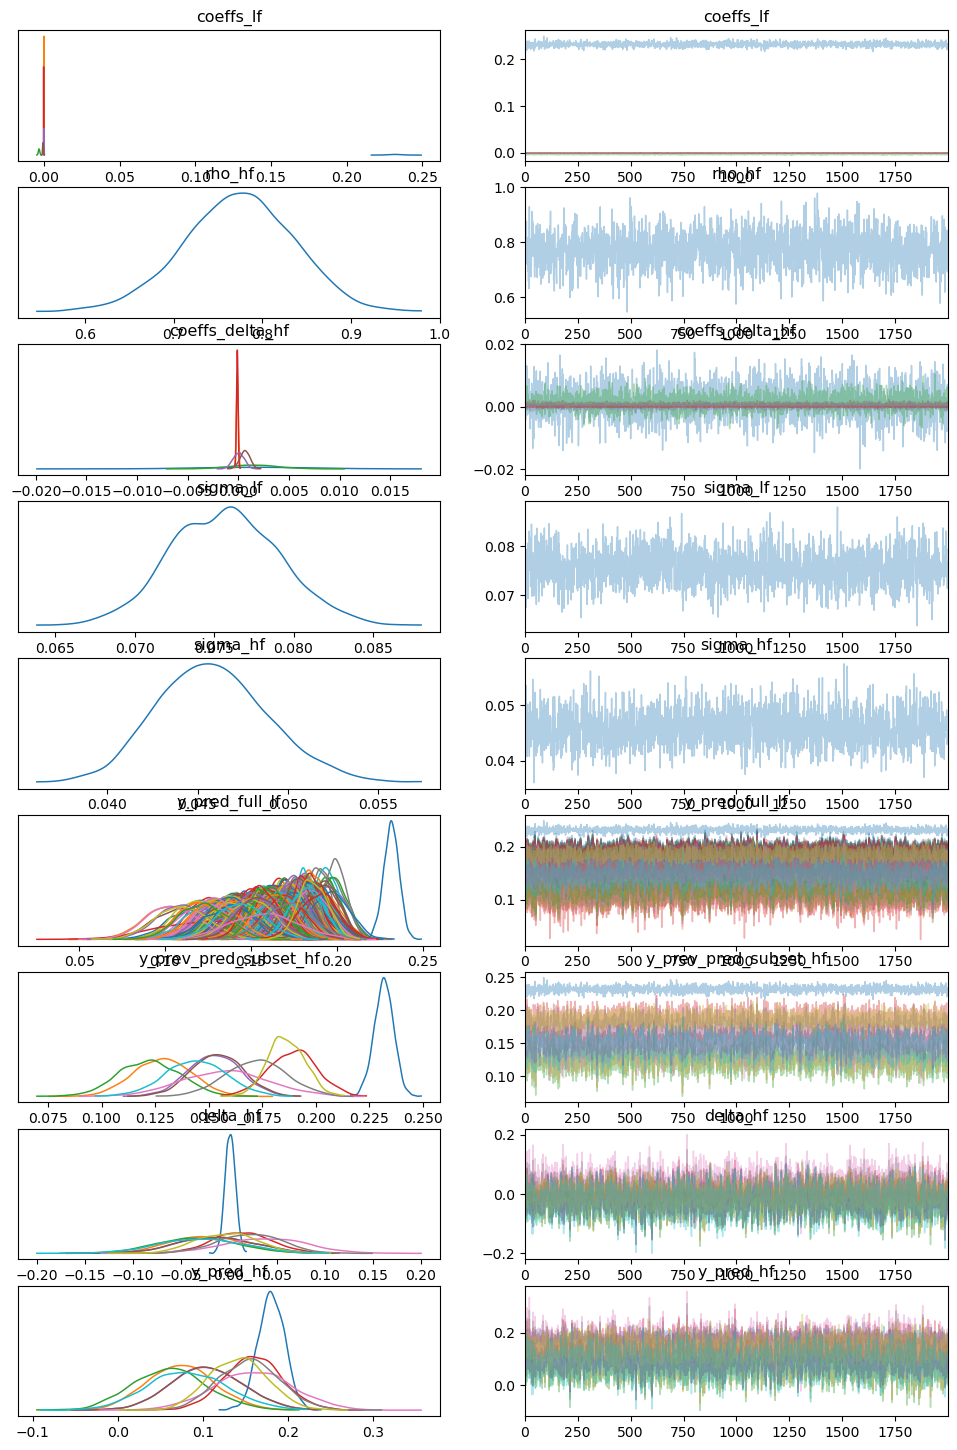

In [11]:
multi_fidelity_model.plot_trace()

In [12]:
multi_fidelity_model.evaluate_mse(x_test, y_test)

0.0020399856951527386

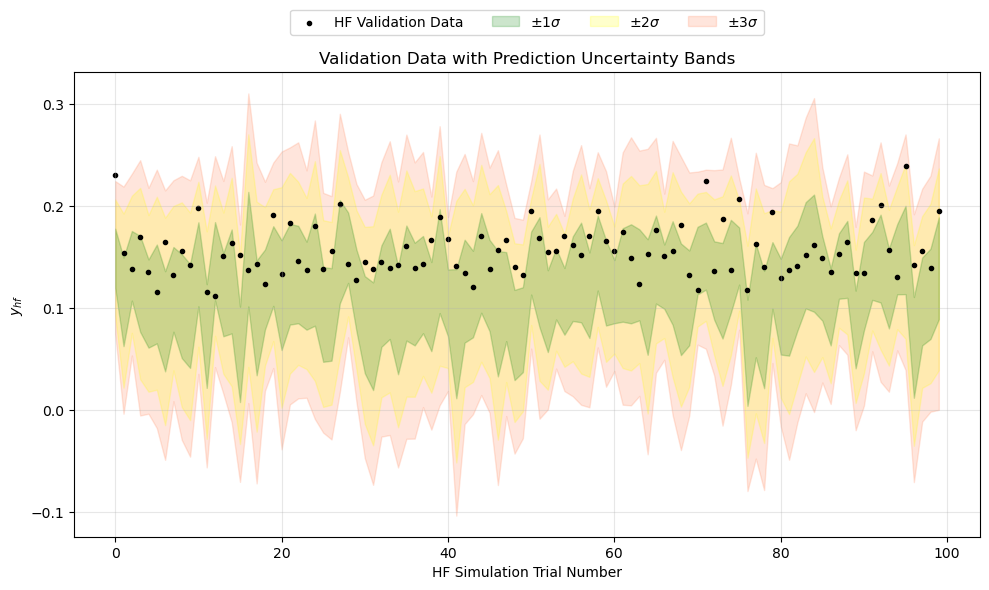

In [13]:
multi_fidelity_model.plot_validation(x_test,y_test)

In [14]:
multi_fidelity_model.validate_coverage(x_test,y_test)

{1: 60.0, 2: 97.0, 3: 99.0}